In [42]:
import pandas as pd
from zipline.pipeline import Pipeline
from zipline.pipeline.data import USEquityPricing

from sharadar.pipeline.factors import (
    MarketCap,
    EV,
    Fundamentals,
    Exchange,
    Sector,
    IsDomesticCommonStock,
    EvEbit,
    FundamentalsTTM,

)
from sharadar.pipeline.engine import load_sharadar_bundle, symbol, symbols, make_pipeline_engine, prices
from zipline.pipeline.filters import StaticAssets
import time
import datetime

import numpy as np

from IPython.display import Markdown, display
from zipline.api import (
    attach_pipeline,
    calendars,
    date_rules,
    get_datetime,
    get_open_orders,
    order_target_percent,
    pipeline_output,
    record,
    schedule_function,
    set_commission,
    set_slippage,
    time_rules,
)
from zipline.pipeline import Pipeline
from zipline.pipeline.data import USEquityPricing
from zipline.pipeline.factors import AverageDollarVolume, CustomFactor, Returns


from sharadar.util.run_algo import run_algorithm



In [2]:
from dateutil.relativedelta import relativedelta

In [4]:
bundle = load_sharadar_bundle()

In [5]:
engine = make_pipeline_engine()

In [6]:
print(engine)

In [7]:
class MagicFormula(CustomFactor):
    """
    Magic Formula factor combining earnings yield and return on capital rankings.
    
    Based on Joel Greenblatt's Magic Formula investing strategy that ranks stocks
    by both cheapness (earnings yield) and quality (return on capital).
    """
    
    inputs = [
        # Fundamental data inputs
        FundamentalsTTM(field='ebit'),
        EV(),
        FundamentalsTTM(field='assets'),
        FundamentalsTTM(field='workingcapital')
    ]
    
    window_length = 1
    
    def compute(self, today, assets, out, ebit, ev, net_fixed_assets, working_capital):
        # Cheapness: Earnings Yield
        earnings_yield = ebit[-1] / ev[-1]
        
        # Quality: Return on Capital
        roc = ebit[-1] / (net_fixed_assets[-1] + working_capital[-1])
        
        # Create mask for valid data (non-NaN, non-zero denominators)
        valid_mask = (
            ~np.isnan(earnings_yield) & 
            ~np.isnan(roc) & 
            (ev[-1] != 0) & 
            ((net_fixed_assets[-1] + working_capital[-1]) != 0)
        )
        
        # Initialize output with NaN
        out[:] = np.nan
        
        if valid_mask.sum() > 0:
            # Rank earnings yield (higher is better)
            ey_ranks = np.full_like(earnings_yield, np.nan)
            ey_ranks[valid_mask] = len(earnings_yield[valid_mask]) + 1 - \
                np.argsort(np.argsort(earnings_yield[valid_mask]))[::-1]
            
            # Rank return on capital (higher is better)
            roc_ranks = np.full_like(roc, np.nan)
            roc_ranks[valid_mask] = len(roc[valid_mask]) + 1 - \
                np.argsort(np.argsort(roc[valid_mask]))[::-1]
            
            # Combine rankings (lower combined score is better)
            combined_score = ey_ranks + roc_ranks
            out[valid_mask] = combined_score[valid_mask]

In [8]:
N_LONGS = 50

In [9]:
def make_pipeline():
    
    magicformula = MagicFormula()
    #dollar_volume = AverageDollarVolume(window_length=30)
    #high_dollar_volume = dollar_volume.top(1000)
    
    # Add exchange and sector filters
    exchange_filter = Exchange().element_of(['NYSE', 'NASDAQ', 'NYSEMKT'])
    sector_filter = ~Sector().element_of(['Financial Services', 'Real Estate'])
    commonstock = (IsDomesticCommonStock().eq(1))
    
    # Market cap filter: exclude companies with market cap below $50 million
    # Note: This was previously MarketCap().top(10) which only selected top 10 companies
    # Now it filters out micro-cap stocks while keeping all stocks above the threshold
    market_cap_filter = MarketCap() > 100_000_000  # $100 million minimum
    
    # Combine all screens
    combined_screen = exchange_filter & sector_filter & commonstock & market_cap_filter

    return Pipeline(
        columns={
            "factor": magicformula,
            "longs": magicformula.top(N_LONGS),
            "ranking": magicformula.rank(),
            "marketcap": MarketCap(),
        },
        screen=combined_screen
    )

In [10]:
#pipe_start = pd.to_datetime('2020-02-03')
#pipe_end = pd.to_datetime('2020-02-04')

In [11]:
#engine.run_pipeline(make_pipeline(),pipe_start,pipe_end)

In [12]:
def before_trading_start(context, data):
    # Get pipeline results
    pipe_results = pipeline_output('factor_pipeline')
    
    # Sort stocks by factor (MagicFormula score) - lower is better
    context.top_stocks = []
    for sec in pipe_results.sort_values(by=["factor"], ascending=True).index.tolist():
        if data.can_trade(sec):
            context.top_stocks.append(sec)
    
    # Initialize rebalance_date on first run
    if context.rebalance_date is None:
        context.rebalance_date = get_datetime().date()
    
    # Check if we should rebalance today
    if context.rebalance_date <= get_datetime().date():
        context.rebalance_today = True
        context.rebalance_date += relativedelta(months=1)
    else:
        context.rebalance_today = False

In [13]:
#from zipline.utils.calendars import get_calendar
from zipline.finance.commission import PerShare
from zipline.finance import commission, slippage

In [14]:
def initialize(context):
    context.holding_period = 12
    context.stocks_per_month = 2
    context.stocks = []
    context.top_stocks = []
    context.rebalance_date = None
    context.rebalance_today = False  # Flag to trigger rebalancing
    
    attach_pipeline(make_pipeline(), "factor_pipeline")
    schedule_function(
        handle_rebalance,
        date_rules.every_day(),
        time_rules.market_open(),
        calendar=calendars.US_EQUITIES,
    )
    set_commission(us_equities=commission.PerShare(cost=0.005, min_trade_cost=1.0))

In [15]:
def rebalance(context, data):
    n = context.holding_period * context.stocks_per_month
    
    # Get top stocks that aren't already held
    new_stocks = [s for s in context.top_stocks if s not in context.stocks][:context.stocks_per_month]  
    
    # For the first year of the backtest, just accumulate
    if len(context.stocks) < n:
        # Helper logic to buy stocks
        target_weight = 1.0 / n
        
        # Order and add to list
        for s in new_stocks:
            order_target_percent(s, target_weight)
            context.stocks.append(s)
    else:
        # Sell first stocks
        stocks_to_sell = context.stocks[:context.stocks_per_month]
        
        # Liquidate and remove from list
        for s in stocks_to_sell:
            order_target_percent(s, 0)
            context.stocks.remove(s)
        
        # Buy new stocks
        target_weight = 1.0 / n
        
        # Order and add to list
        for s in new_stocks:
            order_target_percent(s, target_weight)
            context.stocks.append(s)
    
    print(f"Portfolio size after rebalance: {len(context.stocks)}")

In [16]:
def handle_rebalance(context, data):
    # Only rebalance if the flag is set
    if context.rebalance_today:
        rebalance(context, data)
        context.rebalance_today = False

In [17]:
start = pd.Timestamp("2015-01-04")
end = pd.Timestamp("2025-01-04")

In [18]:
perf = run_algorithm(
        start=start,
        end=end,
        initialize=initialize,
        before_trading_start=before_trading_start,
        capital_base=100000000,
        bundle="sharadar",
)

[2025-08-17 16:35:16] INFO: Using bundle 'sharadar'.
[2025-08-17 16:35:16] INFO: Using trading calendar '2005-08-17 00:00:00'.
[2025-08-17 16:35:16] INFO: Backtest from 2015-01-05 to 2025-01-04.


Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory


[2025-08-17 16:35:20] INFO: Save root mask file: root-2015-01-05_2015-01-12_XNYS_US_0.pkl


Failed to create stream fd: No such file or directory


Pipeline from 2015-01-05 to 2015-01-12
[2025-08-17 16:36:10] INFO: save term-2015-01-05_2015-01-12_screen_16578347c4ca4c99acc7541a2948bfe5_factor.npy to cache
[2025-08-17 16:36:10] INFO: save term-2015-01-05_2015-01-12_screen_16578347c4ca4c99acc7541a2948bfe5_longs.npy to cache
[2025-08-17 16:36:10] INFO: save term-2015-01-05_2015-01-12_screen_16578347c4ca4c99acc7541a2948bfe5_ranking.npy to cache
[2025-08-17 16:36:10] INFO: save term-2015-01-05_2015-01-12_screen_16578347c4ca4c99acc7541a2948bfe5_marketcap.npy to cache
[2025-08-17 16:36:10] INFO: save term-2015-01-05_2015-01-12_screen_16578347c4ca4c99acc7541a2948bfe5_screen_16578347c4ca4c99acc7541a2948bfe5.npy to cache


...

Pipeline from 2024-08-15 to 2025-01-03


/tmp/ipykernel_29444/2775701192.py:21: RuntimeWarning: divide by zero encountered in divide
  earnings_yield = ebit[-1] / ev[-1]


[2025-08-17 17:45:54] INFO: save term-2024-08-15_2025-01-03_screen_16578347c4ca4c99acc7541a2948bfe5_factor.npy to cache
[2025-08-17 17:45:54] INFO: save term-2024-08-15_2025-01-03_screen_16578347c4ca4c99acc7541a2948bfe5_longs.npy to cache
[2025-08-17 17:45:54] INFO: save term-2024-08-15_2025-01-03_screen_16578347c4ca4c99acc7541a2948bfe5_ranking.npy to cache
[2025-08-17 17:45:54] INFO: save term-2024-08-15_2025-01-03_screen_16578347c4ca4c99acc7541a2948bfe5_marketcap.npy to cache
[2025-08-17 17:45:54] INFO: save term-2024-08-15_2025-01-03_screen_16578347c4ca4c99acc7541a2948bfe5_screen_16578347c4ca4c99acc7541a2948bfe5.npy to cache
[2025-08-17 17:45:54] INFO: Pipeline from 2024-08-15 to 2025-01-03 completed in 0:02:07.


Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory
Failed to create stream fd: No such file or directory


Portfolio size after rebalance: 24
Portfolio size after rebalance: 24
Portfolio size after rebalance: 24
Portfolio size after rebalance: 24


In [19]:
import pyfolio as pf

In [74]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
returns, positions, transactions = pf.utils.extract_rets_pos_txn_from_zipline(perf)

In [ ]:
sids = symbol("SPY")
benchmark = prices([sids],start,end).pct_change()

Start date,2015-01-05
End date,2025-01-03
Total months,119
,Backtest
Annual return,12.155%
Cumulative returns,214.484%
Annual volatility,24.425%
Sharpe ratio,0.59
Calmar ratio,0.29
Stability,0.79
Max drawdown,-41.326%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,41.33,2020-02-18,2020-03-20,2020-06-05,79
1,39.32,2021-11-08,2022-12-27,2024-12-24,817
2,23.66,2018-08-24,2018-12-21,2019-05-02,180
3,21.57,2015-06-22,2016-02-10,2016-06-01,248
4,14.06,2020-06-05,2020-07-08,2020-11-13,116


Top 10 long positions of all time,max
sid,
IONQ,18.89%
GERN,15.19%
MED,13.93%
SOUN,13.82%
UEC,12.61%
BXC,11.02%
FLL,10.64%
MGPI,10.46%
NERV,10.32%


Top 10 short positions of all time,max
sid,
MNIQQ,-8.57%


Top 10 positions of all time,max
sid,
IONQ,18.89%
GERN,15.19%
MED,13.93%
SOUN,13.82%
UEC,12.61%
BXC,11.02%
FLL,10.64%
MGPI,10.46%
NERV,10.32%


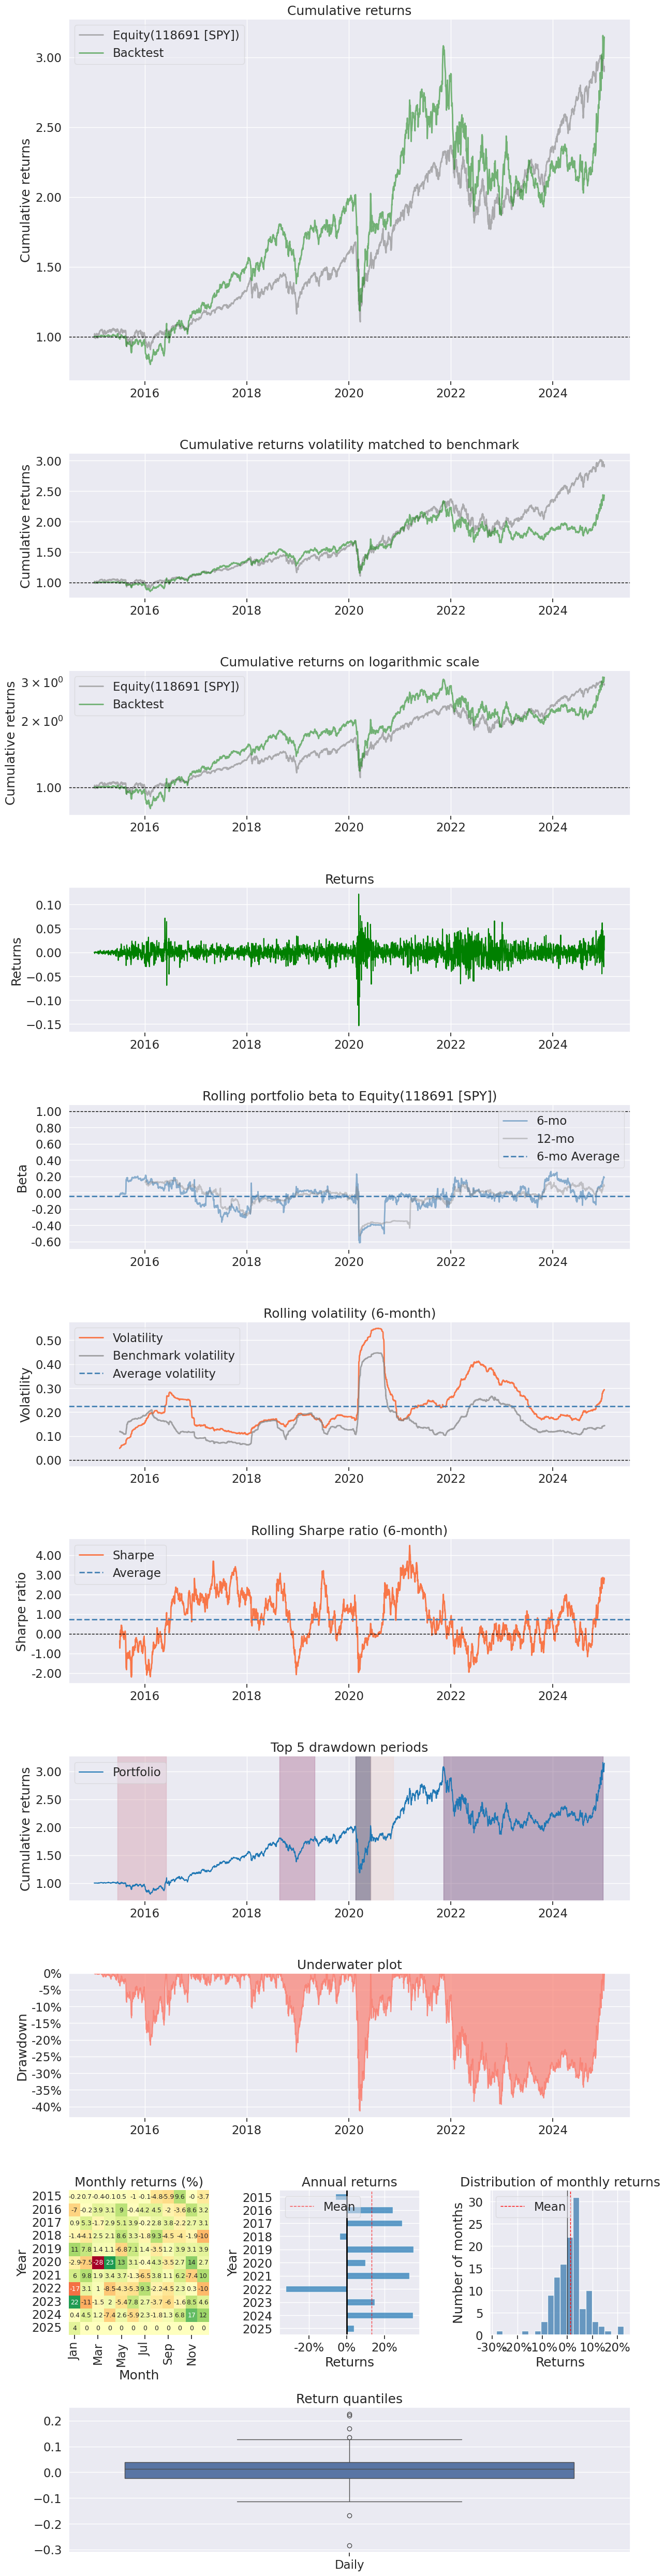

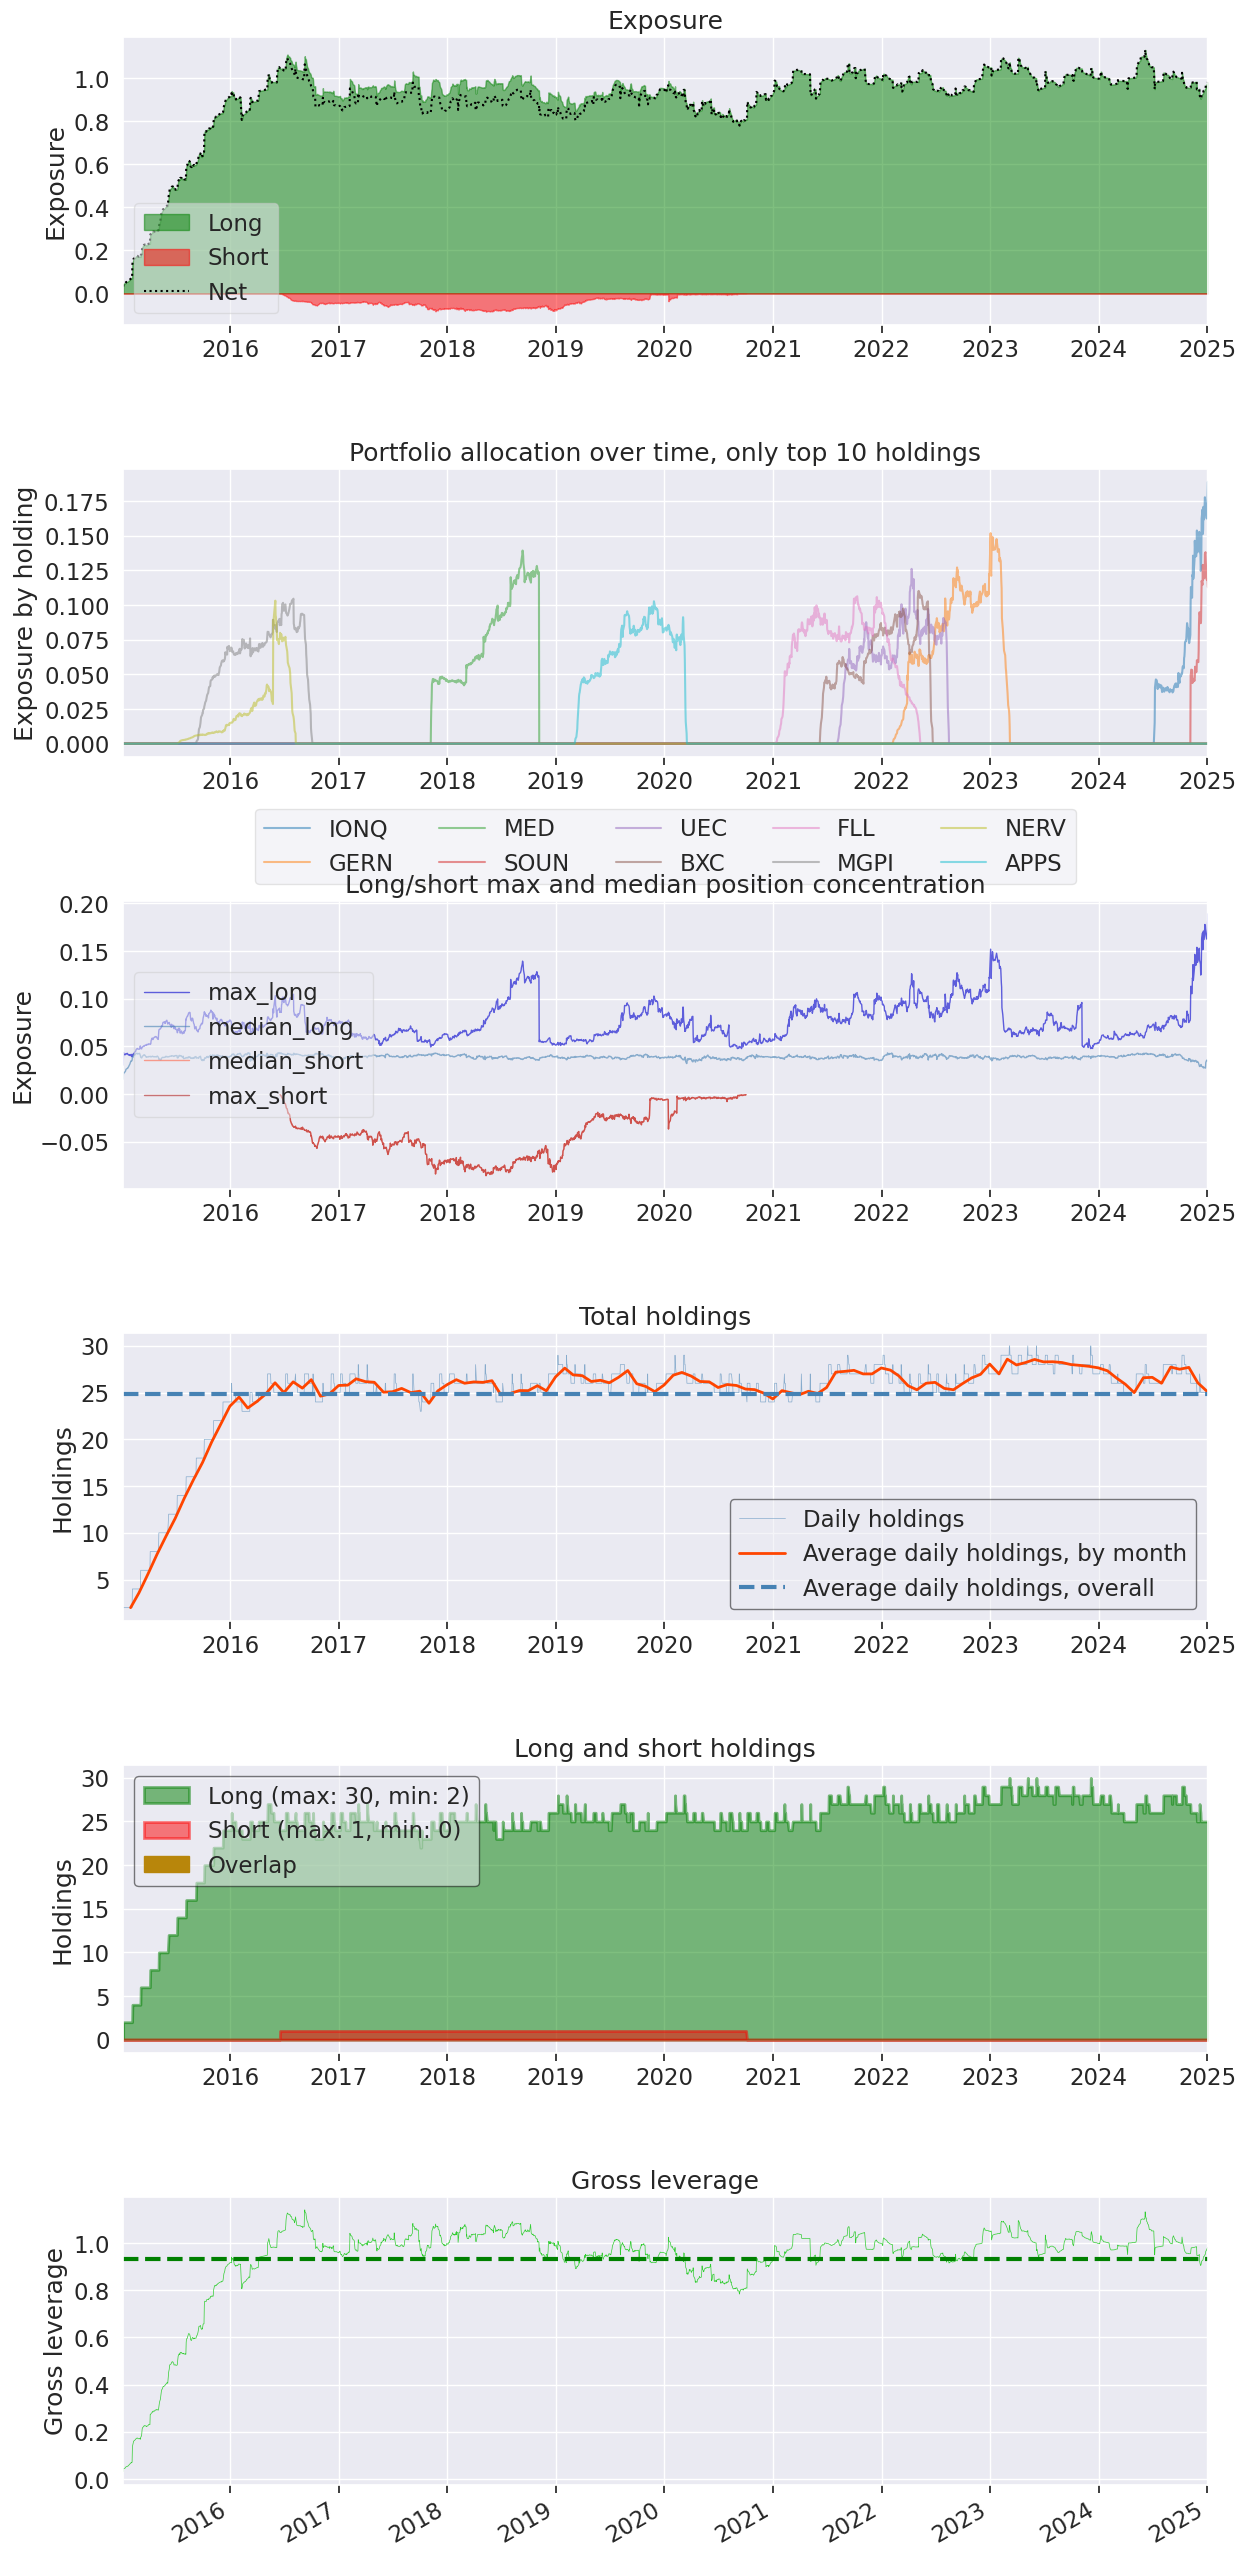

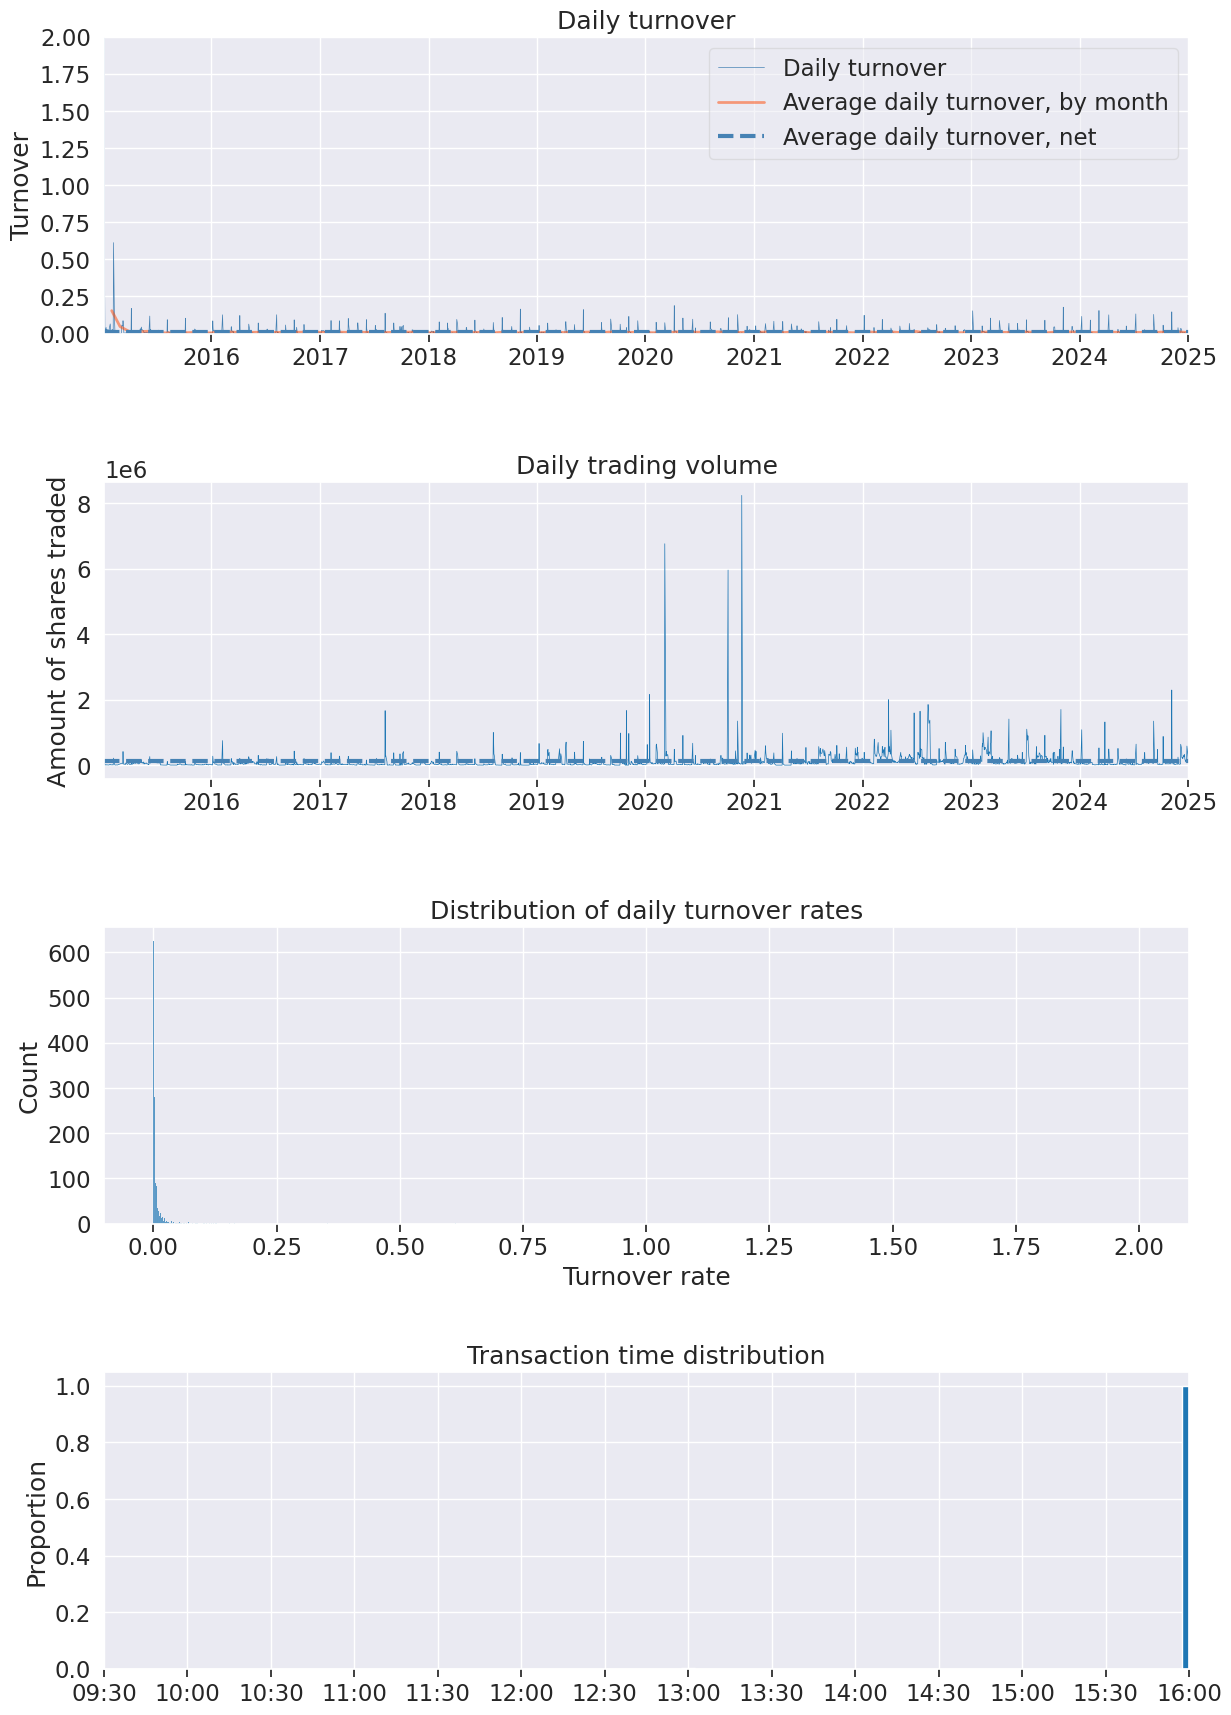

In [75]:
# Before calling create_returns_tear_sheet, ensure all datetime data is timezone-naive
returns = returns.tz_localize(None) if returns.index.tz is not None else returns

# Fix the benchmark data - handle both DataFrame and Series cases
if isinstance(benchmark, pd.DataFrame):
    benchmark_rets = benchmark.iloc[:, 0]  # Extract first column if DataFrame
else:
    benchmark_rets = benchmark  # Use as-is if already a Series

benchmark_rets = benchmark_rets.tz_localize(None) if benchmark_rets.index.tz is not None else benchmark_rets

# Make sure live_start_date is timezone-naive or None
live_start_date = None

pf.create_full_tear_sheet(
    returns,
    benchmark_rets=benchmark_rets,
    positions=positions, 
    transactions=transactions,
    live_start_date=live_start_date
)